In [2]:
# Step 1: Import libraries and load processed dataset

import pandas as pd
import numpy as np

# Load processed dataset
df = pd.read_csv("../data/processed/telco_customer_churn_processed.csv")

print("Dataset loaded successfully.")
print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset loaded successfully.
Dataset Shape: (7021, 31)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [3]:
# Step 2: Separate features and target

X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("Target unique values:", y.unique())
print("Target distribution:")
print(y.value_counts())

Features (X) shape: (7021, 30)
Target (y) shape: (7021,)
Target unique values: [0 1]
Target distribution:
Churn
0    5164
1    1857
Name: count, dtype: int64


In [4]:
# Step 3: Split data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (5616, 30)
Testing Features: (1405, 30)
Training Target: (5616,)
Testing Target: (1405,)


In [5]:
# Step 4: Train baseline models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

# Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
random_forest_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")
print("Random Forest trained successfully.")

c:\Projects\customer-churn-intelligence\.venv312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression trained successfully.
Random Forest trained successfully.


In [6]:
# Step 5: Evaluate baseline models

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predictions
lr_pred = logistic_model.predict(X_test)
rf_pred = random_forest_model.predict(X_test)

# Probabilities for ROC-AUC
lr_prob = logistic_model.predict_proba(X_test)[:, 1]
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

# Evaluation function
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{name}")
    print("-" * 40)
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_true, y_prob))

# Evaluate both models
evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
evaluate_model("Random Forest", y_test, rf_pred, rf_prob)


Logistic Regression
----------------------------------------
Accuracy : 0.801423487544484
Precision: 0.658703071672355
Recall   : 0.5188172043010753
F1 Score : 0.5804511278195489
ROC-AUC  : 0.840376448177872

Random Forest
----------------------------------------
Accuracy : 0.7786476868327402
Precision: 0.6117216117216118
Recall   : 0.4489247311827957
F1 Score : 0.517829457364341
ROC-AUC  : 0.8180825760651199


In [11]:
%pip install matplotlib

  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp312-cp312-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.65.0-cp312-cp312-win_amd64.whl (2.5 MB)
Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl (70 kB)
Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -

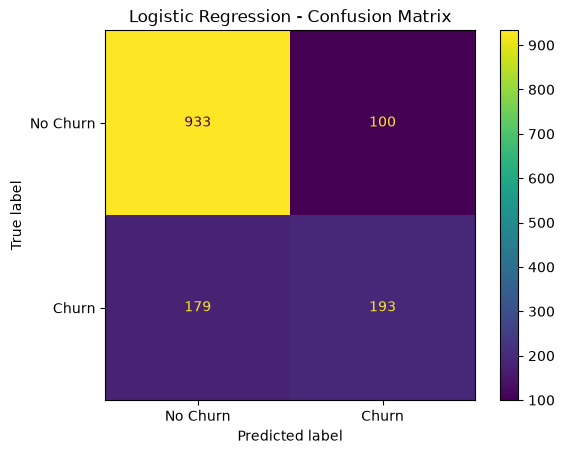

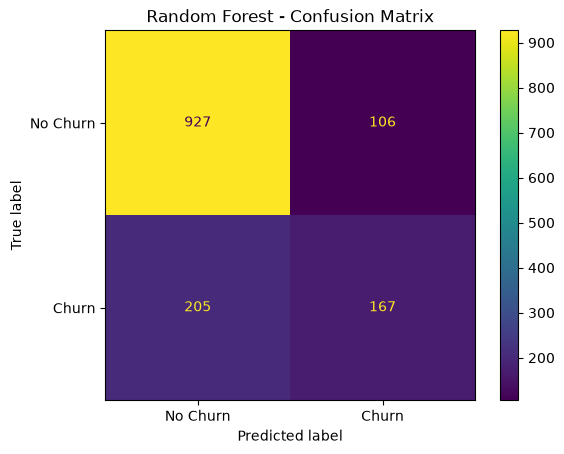

In [12]:
# Step 6: Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["No Churn", "Churn"]
)

disp_lr.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


# Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Churn", "Churn"]
)

disp_rf.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

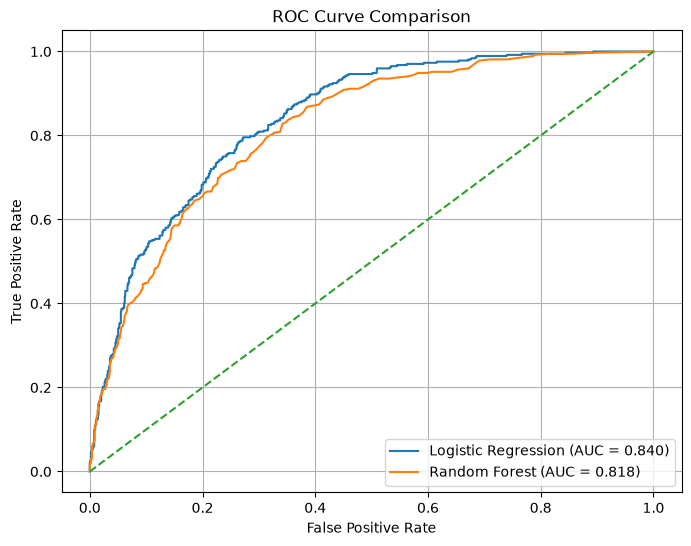

In [13]:
# Step 7: ROC Curve Comparison

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

# Calculate AUC
auc_lr = roc_auc_score(y_test, lr_prob)
auc_rf = roc_auc_score(y_test, rf_prob)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

In [14]:
# Step 8: Select and Save Best Model

import joblib
import os

# Select Logistic Regression as the best model
best_model = logistic_model

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the model
joblib.dump(best_model, "../models/logistic_regression_churn_model.pkl")

print("Best model: Logistic Regression")
print(f"ROC-AUC: {auc_lr:.3f}")
print("Model saved successfully.")

Best model: Logistic Regression
ROC-AUC: 0.840
Model saved successfully.


In [15]:
# Step 9: Load and Verify Saved Model

import joblib
import os

model_path = "../models/logistic_regression_churn_model.pkl"

# Check if model file exists
print("Model file exists:", os.path.exists(model_path))

# Load the saved model
loaded_model = joblib.load(model_path)

print("Saved model loaded successfully.")
print("Model type:", type(loaded_model).__name__)

# Test prediction
sample_predictions = loaded_model.predict(X_test.iloc[:5])

print("Sample predictions:", sample_predictions)

Model file exists: True
Saved model loaded successfully.
Model type: LogisticRegression
Sample predictions: [1 1 0 0 0]


# Modeling Summary

## Models Trained
1. Logistic Regression
2. Random Forest

## Model Comparison

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.801 | 0.659 | 0.519 | 0.580 | 0.840 |
| Random Forest | 0.779 | 0.612 | 0.449 | 0.518 | 0.818 |

## Best Model

Logistic Regression was selected as the best-performing baseline model based on ROC-AUC.

**ROC-AUC: 0.840**

The trained Logistic Regression model was saved as:

`models/logistic_regression_churn_model.pkl`

The saved model was successfully loaded and verified with sample predictions.